In [1]:
import os 
import numpy as np
import torch 
import matplotlib.pyplot as plt
import pandas as pd

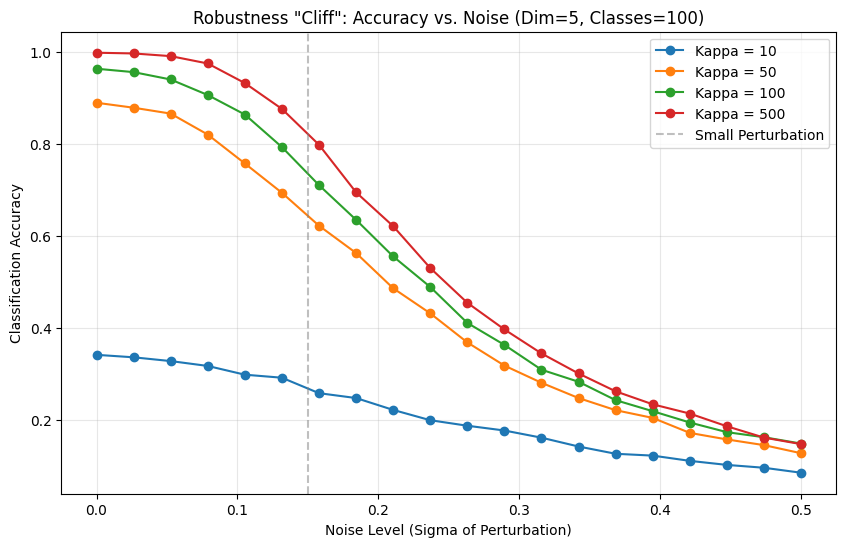

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

def generate_vmf_samples(mu, kappa, num_samples):
    """
    Generates samples from von Mises-Fisher distribution.
    Approximation: For high kappa, vMF is roughly Gaussian on the tangent plane.
    We simulate this by adding Gaussian noise scaled by 1/sqrt(kappa) and re-normalizing.
    """
    dim = len(mu)
    # Generate random noise vectors
    noise = np.random.normal(0, 1, (num_samples, dim))
    
    # Project noise to be orthogonal to mu (tangent space)
    # v_tangent = v - (v . mu) * mu
    noise_proj = noise - np.outer(np.dot(noise, mu), mu)
    
    # Scale noise by approximate width (1/sqrt(kappa))
    # This is a heuristic that works well for kappa > 10 for visualization
    scaled_noise = noise_proj * (1.0 / np.sqrt(kappa))
    
    # Add to mean and re-normalize to unit sphere
    samples = mu + scaled_noise
    samples = samples / np.linalg.norm(samples, axis=1, keepdims=True)
    return samples

def run_experiment():
    # --- Parameters ---
    NUM_CLASSES = 100
    DIMENSION = 5
    SAMPLES_PER_CLASS = 50
    KAPPA_VALUES = [10, 50, 100, 500]
    NOISE_LEVELS = np.linspace(0, 0.5, 20) # Sigma of added noise
    
    # 1. Generate Class Centers (Randomly on Sphere)
    class_centers = np.random.normal(0, 1, (NUM_CLASSES, DIMENSION))
    class_centers = class_centers / np.linalg.norm(class_centers, axis=1, keepdims=True)
    
    plt.figure(figsize=(10, 6))
    
    # 2. Run Simulation for each Kappa
    for kappa in KAPPA_VALUES:
        accuracies = []
        
        # Generate Test Data (Clean)
        X_test = []
        y_test = []
        for i in range(NUM_CLASSES):
            samples = generate_vmf_samples(class_centers[i], kappa, SAMPLES_PER_CLASS)
            X_test.append(samples)
            y_test.append([i] * SAMPLES_PER_CLASS)
            
        X_test = np.vstack(X_test)
        y_test = np.hstack(y_test)
        
        # 3. Test Robustness against Noise
        for sigma in NOISE_LEVELS:
            # Add random Gaussian noise to the test data
            noise = np.random.normal(0, sigma, X_test.shape)
            X_test_noisy = X_test + noise
            # Re-normalize (project back to sphere)
            X_test_noisy = X_test_noisy / np.linalg.norm(X_test_noisy, axis=1, keepdims=True)
            
            # Simple Classifier: Dot Product (Nearest Centroid)
            # We predict the class with the highest cosine similarity to the center
            sims = cosine_similarity(X_test_noisy, class_centers)
            predictions = np.argmax(sims, axis=1)
            
            acc = np.mean(predictions == y_test)
            accuracies.append(acc)
            
        plt.plot(NOISE_LEVELS, accuracies, marker='o', label=f'Kappa = {kappa}')

    # Formatting
    plt.title(f'Robustness "Cliff": Accuracy vs. Noise (Dim={DIMENSION}, Classes={NUM_CLASSES})')
    plt.xlabel('Noise Level (Sigma of Perturbation)')
    plt.ylabel('Classification Accuracy')
    plt.axvline(x=0.15, color='gray', linestyle='--', alpha=0.5, label='Small Perturbation')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

if __name__ == "__main__":
    run_experiment()

Running Experiment: Dim=5, Classes=100, Kappa=10


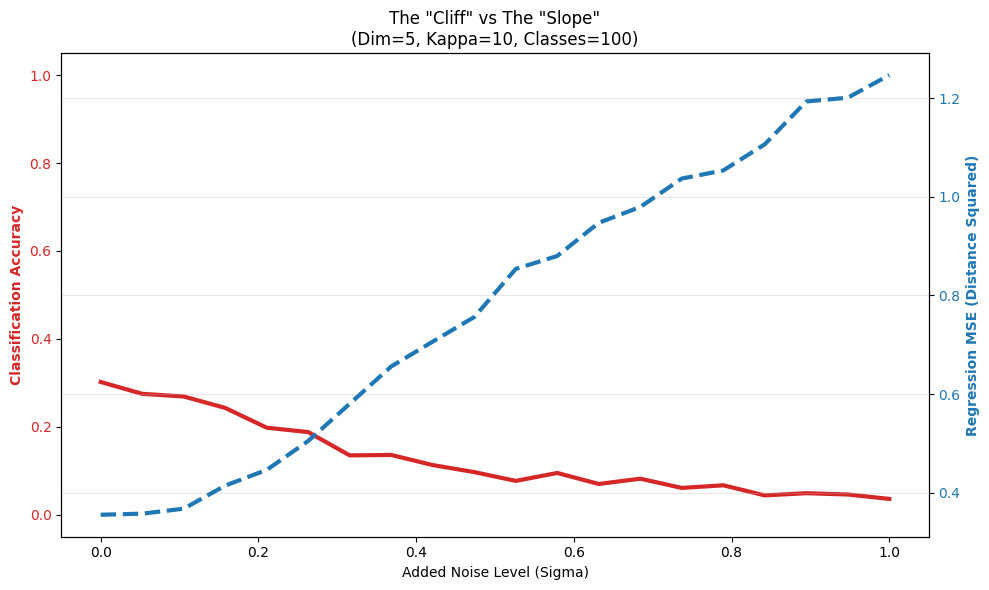

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

def generate_experiment_data(n_classes=100, dim=5, kappa=10):
    # 1. Generate 100 random class centers on the 5D sphere
    centers = np.random.normal(0, 1, (n_classes, dim))
    centers = centers / np.linalg.norm(centers, axis=1, keepdims=True)
    return centers

def get_noisy_samples(center, kappa, noise_sigma, n_samples=1000):
    dim = len(center)
    # vMF approximation: Center + Noise scaled by kappa
    # Base spread determined by Kappa (1/sqrt(kappa))
    base_noise = np.random.normal(0, 1/np.sqrt(kappa), (n_samples, dim))
    
    # Add external perturbation (e.g. measurement noise)
    external_noise = np.random.normal(0, noise_sigma, (n_samples, dim))
    
    samples = center + base_noise + external_noise
    # Project back to sphere
    samples = samples / np.linalg.norm(samples, axis=1, keepdims=True)
    return samples

def run_comparison():
    # Setup
    N_CLASSES = 100
    DIM = 5
    KAPPA = 10  # Low Kappa (High spread)
    NOISE_LEVELS = np.linspace(0, 1.0, 20)
    
    centers = generate_experiment_data(N_CLASSES, DIM, KAPPA)
    target_idx = 0  # We will test samples from Class 0
    true_center = centers[target_idx]
    
    acc_scores = []
    mse_scores = []
    
    print(f"Running Experiment: Dim={DIM}, Classes={N_CLASSES}, Kappa={KAPPA}")
    
    for sigma in NOISE_LEVELS:
        # Generate samples from Class 0 with added noise
        X = get_noisy_samples(true_center, KAPPA, sigma)
        
        # --- METRIC 1: CLASSIFICATION (Discrete) ---
        # Did we find the correct name? (Nearest Neighbor)
        sims = cosine_similarity(X, centers)
        preds = np.argmax(sims, axis=1)
        accuracy = np.mean(preds == target_idx)
        acc_scores.append(accuracy)
        
        # --- METRIC 2: REGRESSION (Continuous) ---
        # How far is the guess from the true coordinate? (MSE)
        # We treat the sample itself as the "guess" for the center
        squared_errors = np.sum((X - true_center)**2, axis=1)
        mse = np.mean(squared_errors)
        mse_scores.append(mse)

    # Plotting
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Axis 1: Accuracy (The Cliff)
    color = 'tab:red'
    ax1.set_xlabel('Added Noise Level (Sigma)')
    ax1.set_ylabel('Classification Accuracy', color=color, fontweight='bold')
    ax1.plot(NOISE_LEVELS, acc_scores, color=color, linewidth=3, label='Accuracy (Cliff)')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.set_ylim(-0.05, 1.05)

    # Axis 2: MSE (The Slope)
    ax2 = ax1.twinx()  
    color = 'tab:blue'
    ax2.set_ylabel('Regression MSE (Distance Squared)', color=color, fontweight='bold')
    ax2.plot(NOISE_LEVELS, mse_scores, color=color, linewidth=3, linestyle='--', label='MSE (Slope)')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title(f'The "Cliff" vs The "Slope"\n(Dim={DIM}, Kappa={KAPPA}, Classes={N_CLASSES})')
    plt.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_comparison()

In [15]:
from __future__ import annotations

import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Parsing
# -----------------------------
COORD_RE = re.compile(r"^Coordinate\s+(\d+)\s+(.+?)\s*$")
# Example: train PearsonRResult(statistic=np.float64(0.9451), pvalue=np.float64(0.0))
SPLIT_RE = re.compile(
    r"^(train|val|adv)\s+PearsonRResult\("
    r"statistic=np\.float64\(([-+0-9.eE]+)\),\s*"
    r"pvalue=np\.float64\(([-+0-9.eE]+)\)\)"
)

def parse_identifiability_file(path: Path) -> list[dict]:
    rows: list[dict] = []

    current_coord_idx = None
    current_coord_name = None

    # Define experiment name from the folder holding the file.
    # Adjust if you prefer a different naming scheme.
    experiment = path.parent.name  # e.g., diet_dsprites_model_cnn_crop_rep_0

    with path.open("r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            m_coord = COORD_RE.match(line)
            if m_coord:
                current_coord_idx = int(m_coord.group(1))
                current_coord_name = m_coord.group(2).strip()
                continue

            m_split = SPLIT_RE.match(line)
            if m_split and current_coord_idx is not None:
                split = m_split.group(1)
                statistic = float(m_split.group(2))
                pvalue = float(m_split.group(3))
                rows.append(
                    {
                        "experiment": experiment,
                        "file": str(path),
                        "coordinate_idx": current_coord_idx,
                        "coordinate": current_coord_name,
                        "split": split,
                        "pearson_r": statistic,
                        "pvalue": pvalue,
                    }
                )

    return rows


def parse_all(root: Path, pattern: str = "**/identifiability.txt") -> pd.DataFrame:
    files = sorted(root.glob(pattern))
    if not files:
        raise FileNotFoundError(f"No files found under {root} matching: {pattern}")

    all_rows: list[dict] = []
    for p in files:
        all_rows.extend(parse_identifiability_file(p))

    df = pd.DataFrame(all_rows)

    # Basic sanity checks
    if df.empty:
        raise ValueError("Parsed zero rows. Check regexes vs your log format.")
    expected_splits = {"train", "val", "adv"}
    if not set(df["split"].unique()).issubset(expected_splits):
        print("Warning: unexpected split labels found:", df["split"].unique())

    return df


# -----------------------------
# Visualization helpers
# -----------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def plot_heatmap_annotated(
    agg: pd.DataFrame,
    split: str,
    outdir: Path,
    annotate: str = "mean",  # "mean" or "mean±std"
    value_decimals: int = 2,
    text_decimals: int = 2,
):
    """
    Heatmap: coordinates (rows) x conditions (cols) using aggregated mean across reps.
    Adds numbers inside each cell.
    """
    sub = agg[agg["split"] == split].copy()

    mean_piv = sub.pivot_table(
        index="coordinate", columns="condition", values="pearson_r_mean", aggfunc="mean"
    )

    std_piv = sub.pivot_table(
        index="coordinate", columns="condition", values="pearson_r_std", aggfunc="mean"
    )

    # Stable coordinate ordering by coordinate_idx if available in agg
    # Build an order list from the subframe:
    coord_order = (
        sub[["coordinate_idx", "coordinate"]]
        .drop_duplicates()
        .sort_values("coordinate_idx")["coordinate"]
        .tolist()
    )
    mean_piv = mean_piv.reindex(coord_order)
    std_piv = std_piv.reindex(coord_order)

    # Sort conditions alphabetically (or implement your preferred ordering)
    mean_piv = mean_piv.reindex(sorted(mean_piv.columns), axis=1)
    std_piv = std_piv.reindex(mean_piv.columns, axis=1)

    data = mean_piv.values.astype(float)

    fig, ax = plt.subplots(figsize=(max(9, 0.6 * mean_piv.shape[1]), 5.0))
    im = ax.imshow(data, aspect="auto")

    ax.set_xticks(range(mean_piv.shape[1]))
    ax.set_xticklabels(mean_piv.columns, rotation=45, ha="right")
    ax.set_yticks(range(mean_piv.shape[0]))
    ax.set_yticklabels(mean_piv.index)
    ax.set_title(f"Pearson r (mean across reps) — {split}")
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("pearson_r_mean")

    # Add annotations
    for i in range(mean_piv.shape[0]):
        for j in range(mean_piv.shape[1]):
            mean_val = mean_piv.iloc[i, j]
            std_val = std_piv.iloc[i, j]

            if pd.isna(mean_val):
                text = ""
            else:
                if annotate == "mean±std":
                    text = f"{mean_val:.{text_decimals}f}±{std_val:.{text_decimals}f}"
                else:
                    text = f"{mean_val:.{text_decimals}f}"

            # Simple contrast heuristic: choose white text on darker cells
            # (No fixed colors; text color is fine.)
            try:
                normalized = (mean_val - np.nanmin(data)) / (np.nanmax(data) - np.nanmin(data) + 1e-12)
            except Exception:
                normalized = 0.5
            text_color = "white" if normalized > 0.6 else "black"

            ax.text(j, i, text, ha="center", va="center", fontsize=9, color=text_color)

    fig.tight_layout()
    suffix = "meanpmstd" if annotate == "mean±std" else "mean"
    #outpath = outdir / f"heatmap_{split}_{suffix}.png"
    #fig.savefig(outpath, dpi=200)
    plt.show()
    return outpath



def plot_grouped_bars(df: pd.DataFrame, outdir: Path):
    """
    Grouped bars per experiment, showing train/val/adv for each coordinate.
    Produces one figure per coordinate to keep it readable.
    """
    coords = sorted(df["coordinate"].unique())
    splits = ["train", "val", "adv"]

    for coord in coords:
        sub = df[df["coordinate"] == coord].copy()
        pivot = sub.pivot_table(index="experiment", columns="split", values="pearson_r", aggfunc="mean")
        pivot = pivot.reindex(columns=[c for c in splits if c in pivot.columns])
        pivot = pivot.sort_index()

        fig, ax = plt.subplots(figsize=(max(8, 0.6 * len(pivot.index)), 4.5))
        pivot.plot(kind="bar", ax=ax)
        ax.set_title(f"Pearson r by split — {coord}")
        ax.set_ylabel("pearson_r")
        ax.set_xlabel("experiment")
        ax.legend(title="split")
        fig.tight_layout()

        outpath = outdir / f"bars_{coord}.png"
        #fig.savefig(outpath, dpi=200)
        #plt.close(fig)
        plt.show()

def plot_lines_per_experiment(df: pd.DataFrame, outdir: Path, split: str = "adv"):
    """
    For each experiment, a line over coordinates for a chosen split (often adv is most interesting).
    """
    experiments = sorted(df["experiment"].unique())
    coords_order = (
        df[["coordinate_idx", "coordinate"]]
        .drop_duplicates()
        .sort_values("coordinate_idx")["coordinate"]
        .tolist()
    )

    for exp in experiments:
        sub = df[(df["experiment"] == exp) & (df["split"] == split)].copy()
        pivot = sub.pivot_table(index="coordinate", values="pearson_r", aggfunc="mean")
        pivot = pivot.reindex(coords_order)

        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(pivot.index, pivot["pearson_r"], marker="o")
        ax.set_title(f"{exp} — Pearson r across coordinates ({split})")
        ax.set_ylabel("pearson_r")
        ax.set_xlabel("coordinate")
        ax.set_ylim(0.0, 1.0)
        ax.tick_params(axis="x", rotation=30)
        fig.tight_layout()

        outpath = outdir / f"line_{exp}_{split}.png"
        fig.savefig(outpath, dpi=200)
        plt.close(fig)







Mean Pearson r by condition and split (means are across coordinates and reps):
split                               adv   train     val
condition                                              
diet_shapes3d_model_cnn_crop     0.8746  0.8663  0.8840
diet_shapes3d_model_cnn_dus      0.8321  0.7805  0.8274
diet_shapes3d_model_cnn_none     0.7994  0.8018  0.8014
diet_shapes3d_model_cnn_simclr   0.8785  0.8776  0.8777
diet_shapes3d_model_cnn_simclr2  0.7778  0.7316  0.8453
diet_shapes3d_model_cnn_simclr3  0.8697  0.8235  0.9645
diet_shapes3d_model_cnn_sup      0.8793  0.8695  0.8865
diet_shapes3d_model_cnn_sup2     0.8959  0.8897  0.9095


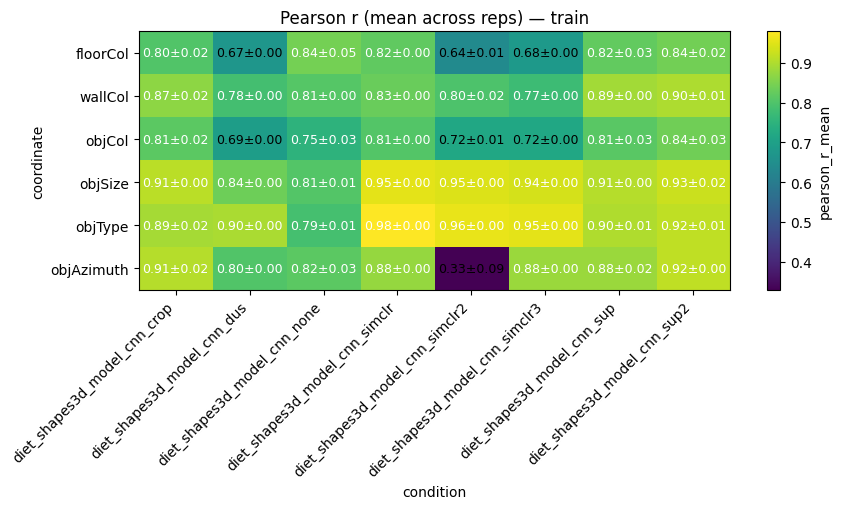

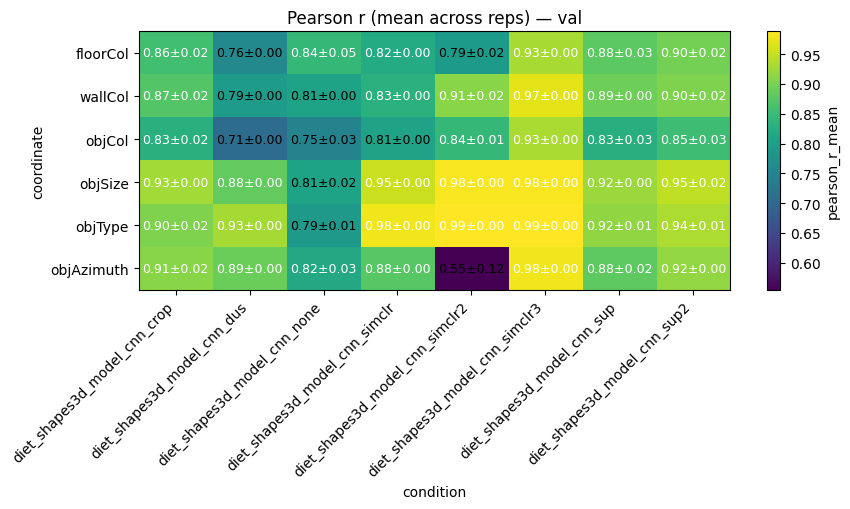

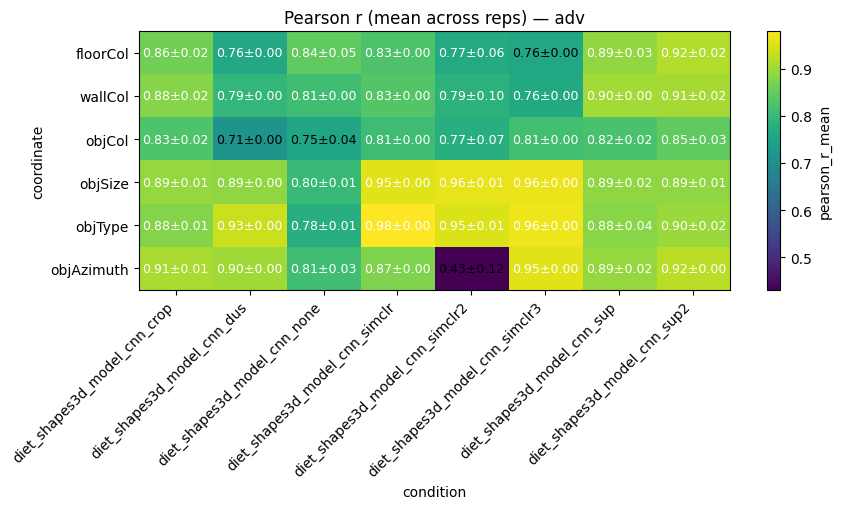

In [28]:
from __future__ import annotations

import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Config
# -----------------------------
ROOT = Path(".")                   # change if needed
GLOB_PATTERN = "**/*shapes3d*/identifiability.txt"
ANNOTATE_STYLE = "mean±std"        # "mean" or "mean±std"
TEXT_DECIMALS = 2

# -----------------------------
# Regex parsers (match your log format)
# -----------------------------
COORD_RE = re.compile(r"^Coordinate\s+(\d+)\s+(.+?)\s*$")
SPLIT_RE = re.compile(
    r"^(train|val|adv)\s+PearsonRResult\("
    r"statistic=np\.float64\(([-+0-9.eE]+)\),\s*"
    r"pvalue=np\.float64\(([-+0-9.eE]+)\)\)"
)
REP_RE = re.compile(r"^(?P<condition>.+?)_rep_(?P<rep>\d+)$")


def parse_identifiability_file(path: Path) -> list[dict]:
    rows: list[dict] = []
    current_coord_idx = None
    current_coord_name = None

    experiment = path.parent.name  # folder name holding identifiability.txt

    with path.open("r", encoding="utf-8", errors="ignore") as f:
        for raw in f:
            line = raw.strip()
            if not line:
                continue

            m_coord = COORD_RE.match(line)
            if m_coord:
                current_coord_idx = int(m_coord.group(1))
                current_coord_name = m_coord.group(2).strip()
                continue

            m_split = SPLIT_RE.match(line)
            if m_split and current_coord_idx is not None:
                split = m_split.group(1)
                statistic = float(m_split.group(2))
                pvalue = float(m_split.group(3))
                rows.append(
                    dict(
                        experiment=experiment,
                        file=str(path),
                        coordinate_idx=current_coord_idx,
                        coordinate=current_coord_name,
                        split=split,
                        pearson_r=statistic,
                        pvalue=pvalue,
                    )
                )

    return rows


def parse_all(root: Path, pattern: str) -> pd.DataFrame:
    files = sorted(root.glob(pattern))
    if not files:
        raise FileNotFoundError(f"No files found under {root} matching: {pattern}")

    all_rows: list[dict] = []
    for p in files:
        all_rows.extend(parse_identifiability_file(p))

    df = pd.DataFrame(all_rows)
    if df.empty:
        raise ValueError("Parsed zero rows. Check regexes vs your log format.")
    return df


def add_condition_and_rep(df: pd.DataFrame) -> pd.DataFrame:
    m = df["experiment"].str.extract(REP_RE)
    out = df.copy()
    out["condition"] = m["condition"].fillna(out["experiment"])
    out["rep"] = pd.to_numeric(m["rep"], errors="coerce")
    return out


def aggregate_across_reps(df: pd.DataFrame) -> pd.DataFrame:
    agg = (
        df.groupby(["condition", "split", "coordinate_idx", "coordinate"], as_index=False)
          .agg(
              pearson_r_mean=("pearson_r", "mean"),
              pearson_r_std=("pearson_r", "std"),
              n=("pearson_r", "count"),
          )
    )
    # std is NaN when n=1
    agg["pearson_r_std"] = agg["pearson_r_std"].fillna(0.0)
    return agg


# -----------------------------
# Plotting
# -----------------------------
def _coord_order(agg: pd.DataFrame) -> list[str]:
    return (
        agg[["coordinate_idx", "coordinate"]]
        .drop_duplicates()
        .sort_values("coordinate_idx")["coordinate"]
        .tolist()
    )

def plot_heatmap_annotated(
    agg: pd.DataFrame,
    split: str,
    annotate: str = "mean±std",
    decimals: int = 2,
):
    """
    Heatmap: coordinates (rows) x conditions (cols)
    Values: mean across reps for the requested split, with numeric annotations.
    """
    sub = agg[agg["split"] == split].copy()
    if sub.empty:
        raise ValueError(f"No rows for split={split}")

    coord_order = _coord_order(agg)

    mean_p = sub.pivot_table(index="coordinate", columns="condition", values="pearson_r_mean", aggfunc="median")
    std_p  = sub.pivot_table(index="coordinate", columns="condition", values="pearson_r_std",  aggfunc="median")

    mean_p = mean_p.reindex(coord_order)
    std_p = std_p.reindex(coord_order)

    # Sort conditions alphabetically (change if you want custom ordering)
    mean_p = mean_p.reindex(sorted(mean_p.columns), axis=1)
    std_p = std_p.reindex(mean_p.columns, axis=1)

    data = mean_p.to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(max(9, 0.6 * mean_p.shape[1]), 5.2))
    im = ax.imshow(data, aspect="auto")

    ax.set_title(f"Pearson r (mean across reps) — {split}")
    ax.set_xlabel("condition")
    ax.set_ylabel("coordinate")

    ax.set_xticks(range(mean_p.shape[1]))
    ax.set_xticklabels(mean_p.columns, rotation=45, ha="right")
    ax.set_yticks(range(mean_p.shape[0]))
    ax.set_yticklabels(mean_p.index)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("pearson_r_mean")

    # Contrast heuristic for text color
    finite = data[np.isfinite(data)]
    vmin = float(np.min(finite)) if finite.size else 0.0
    vmax = float(np.max(finite)) if finite.size else 1.0
    denom = (vmax - vmin) if (vmax - vmin) != 0 else 1.0

    for i in range(mean_p.shape[0]):
        for j in range(mean_p.shape[1]):
            mean_val = mean_p.iat[i, j]
            std_val = std_p.iat[i, j]
            if pd.isna(mean_val):
                continue

            if annotate == "mean±std":
                text = f"{mean_val:.{decimals}f}±{std_val:.{decimals}f}"
            else:
                text = f"{mean_val:.{decimals}f}"

            norm = (mean_val - vmin) / denom
            color = "white" if norm > 0.60 else "black"

            ax.text(j, i, text, ha="center", va="center", fontsize=9, color=color)

    fig.tight_layout()
    plt.show()


def plot_grouped_bars_by_coordinate(agg: pd.DataFrame):
    """
    For each coordinate, plot grouped bars (train/val/adv) per condition.
    Error bars show std across reps.
    """
    coords = _coord_order(agg)
    splits = ["train", "val", "adv"]

    for coord in coords:
        sub = agg[agg["coordinate"] == coord].copy()
        if sub.empty:
            continue

        mean_p = sub.pivot_table(index="condition", columns="split", values="pearson_r_mean", aggfunc="median")
        std_p  = sub.pivot_table(index="condition", columns="split", values="pearson_r_std",  aggfunc="median")

        mean_p = mean_p.reindex(sorted(mean_p.index))
        std_p = std_p.reindex(mean_p.index)

        mean_p = mean_p.reindex(columns=[s for s in splits if s in mean_p.columns])
        std_p = std_p.reindex(columns=mean_p.columns)

        ax = mean_p.plot(kind="bar", figsize=(max(10, 0.6 * len(mean_p.index)), 4.8), yerr=std_p)
        ax.set_title(f"Pearson r (mean±std across reps) — {coord}")
        ax.set_ylabel("pearson_r")
        ax.set_xlabel("condition")
        ax.legend(title="split")
        plt.tight_layout()
        plt.show()


def plot_lines_per_condition(agg: pd.DataFrame, split: str = "adv"):
    """
    For each condition, plot a line across coordinates for a chosen split (often 'adv').
    Values are means across reps.
    """
    coords = _coord_order(agg)
    conditions = sorted(agg["condition"].unique())

    for cond in conditions:
        sub = agg[(agg["condition"] == cond) & (agg["split"] == split)].copy()
        if sub.empty:
            continue

        sub = sub.set_index("coordinate").reindex(coords)
        y = sub["pearson_r_mean"].to_numpy(dtype=float)

        fig, ax = plt.subplots(figsize=(7.6, 4.2))
        ax.plot(coords, y, marker="o")
        ax.set_title(f"{cond} — Pearson r across coordinates ({split}, mean across reps)")
        ax.set_ylabel("pearson_r_mean")
        ax.set_xlabel("coordinate")
        ax.set_ylim(0.0, 1.0)
        ax.tick_params(axis="x", rotation=30)
        fig.tight_layout()
        plt.show()


# -----------------------------
# Run everything
# -----------------------------
df_raw = parse_all(ROOT, GLOB_PATTERN)
df_raw = add_condition_and_rep(df_raw)
agg = aggregate_across_reps(df_raw)

# Optional: quick summary table in console
summary = (
    agg.groupby(["condition", "split"], as_index=False)["pearson_r_mean"].mean()
       .pivot(index="condition", columns="split", values="pearson_r_mean")
       .sort_index()
)
print("Mean Pearson r by condition and split (means are across coordinates and reps):")
print(summary.round(4).to_string())

# Heatmaps with numbers
for sp in ["train", "val", "adv"]:
    plot_heatmap_annotated(agg, sp, annotate=ANNOTATE_STYLE, decimals=TEXT_DECIMALS)

# Bars (one figure per coordinate)
#plot_grouped_bars_by_coordinate(agg)

# Lines (one figure per condition) for adv by default
#plot_lines_per_condition(agg, split="adv")


In [17]:
df_raw[df_raw.experiment == 'diet_dsprites_model_cnn_sup2_rep_2']

,experiment,file,coordinate_idx,coordinate,split,pearson_r,pvalue,condition,rep


In [18]:
agg[(agg.condition == 'diet_dsprites_model_cnn_crop') & (agg.n == 3)]

,condition,split,coordinate_idx,coordinate,pearson_r_mean,pearson_r_std,n


In [19]:
# geom > sup > crop > none  : shape
experiments = np.unique(agg.condition)
print(experiments)

for experiment in experiments:
    agg_ = agg[agg.condition == experiment].copy()
    
    print(experiment, 
          np.mean(agg_[(agg_.split == 'val') & 
              ((agg_.coordinate_idx > 0)  )].iloc[:, 4]))


['diet_shapes3d_model_cnn_crop' 'diet_shapes3d_model_cnn_dus'
 'diet_shapes3d_model_cnn_none' 'diet_shapes3d_model_cnn_simclr'
 'diet_shapes3d_model_cnn_simclr2' 'diet_shapes3d_model_cnn_simclr3'
 'diet_shapes3d_model_cnn_sup' 'diet_shapes3d_model_cnn_sup2']
diet_shapes3d_model_cnn_crop 0.8894358900848193
diet_shapes3d_model_cnn_dus 0.8410697797354555
diet_shapes3d_model_cnn_none 0.7930414551441028
diet_shapes3d_model_cnn_simclr 0.888927645366525
diet_shapes3d_model_cnn_simclr2 0.8562131953804377
diet_shapes3d_model_cnn_simclr3 0.9712079335328031
diet_shapes3d_model_cnn_sup 0.8880484929154993
diet_shapes3d_model_cnn_sup2 0.911688333872922


In [41]:
ds = 'shapes3d'
experiments = [
    f'diet_{ds}_model_cnn_none',
    f'diet_{ds}_model_cnn_crop',
    f'diet_{ds}_model_cnn_sup',
    f'diet_{ds}_model_cnn_sup2',
    f'diet_{ds}_model_cnn_simclr2',
]


for experiment in experiments:
    agg_ = agg[agg.condition == experiment].copy()
    
    print(experiment, 
          np.mean(agg_[(agg_.split == 'val') & 
              ((agg_.coordinate_idx > 0) & (agg_.coordinate_idx != 2)  )].iloc[:, 4]))

diet_shapes3d_model_cnn_none 0.8043037419496896
diet_shapes3d_model_cnn_crop 0.9041733403214429
diet_shapes3d_model_cnn_sup 0.9032279040957895
diet_shapes3d_model_cnn_sup2 0.9261492576980205
diet_shapes3d_model_cnn_simclr2 0.8594767652711899


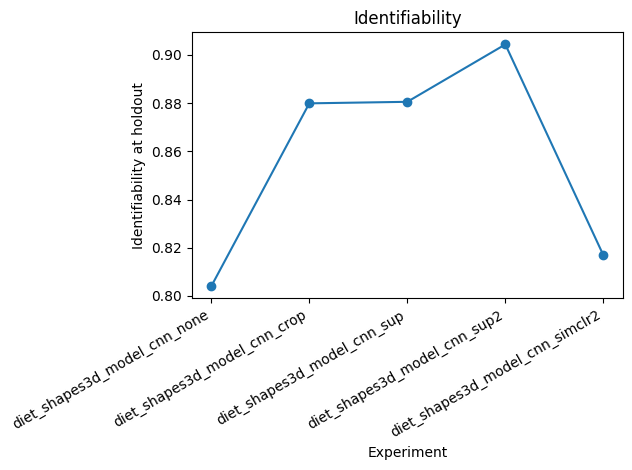

[np.float64(0.8040178928804584),
 np.float64(0.87990646307998),
 np.float64(0.8805421977522085),
 np.float64(0.9043518889109514),
 np.float64(0.8169208258609478)]

In [42]:

import numpy as np
import matplotlib.pyplot as plt

x = []
y = []

for i, experiment in enumerate(experiments):
    agg_ = agg[agg.condition == experiment]

    agg_ = agg[agg.condition == experiment]
    
    vals = np.mean(
        agg_[
            (agg_.split == 'val') & (agg_.coordinate_idx !=4)
            #((agg_.coordinate_idx > 0) & (agg_.coordinate_idx != 2)  ) dsprites
        ].iloc[:, 4]
    )

    mean_val = vals.mean()  # equivalent to np.mean(vals)

    x.append(i)
    y.append(mean_val)

plt.figure()

# line connecting points (with markers)
plt.plot(x, y, marker='o')

# optional: keep scatter too (redundant, but fine)
# plt.scatter(x, y)

plt.xticks(x, experiments, rotation=30, ha="right")
plt.xlabel("Experiment")
plt.ylabel("Identifiability at holdout")
plt.title("Identifiability")

plt.tight_layout()
plt.show()
y

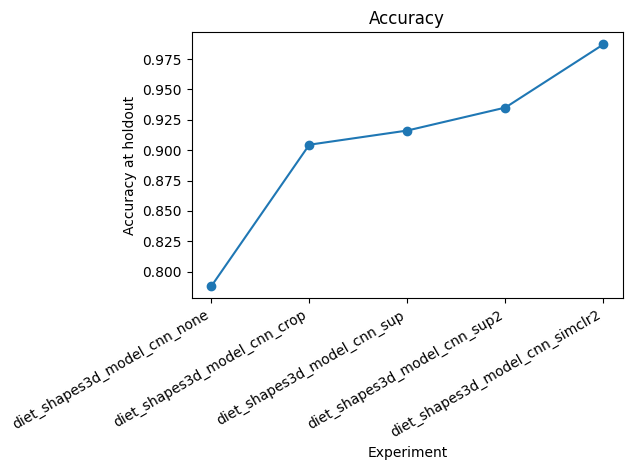

In [43]:
import numpy as np
import matplotlib.pyplot as plt



x = []
y = []

for i, experiment in enumerate(experiments):
    agg_ = agg[agg.condition == experiment]

    vals = agg_[
        (agg_.split == 'val') & (agg_.coordinate_idx ==4)
        #(agg_.coordinate_idx == 0)
    ].iloc[:, 4]


    mean_val = vals.mean()  # equivalent to np.mean(vals)

    x.append(i)
    y.append(mean_val)

plt.figure()

# line connecting points (with markers)
plt.plot(x, y, marker='o')

# optional: keep scatter too (redundant, but fine)
# plt.scatter(x, y)

plt.xticks(x, experiments, rotation=30, ha="right")
plt.xlabel("Experiment")
plt.ylabel("Accuracy at holdout")
plt.title("Accuracy")

plt.tight_layout()
plt.show()


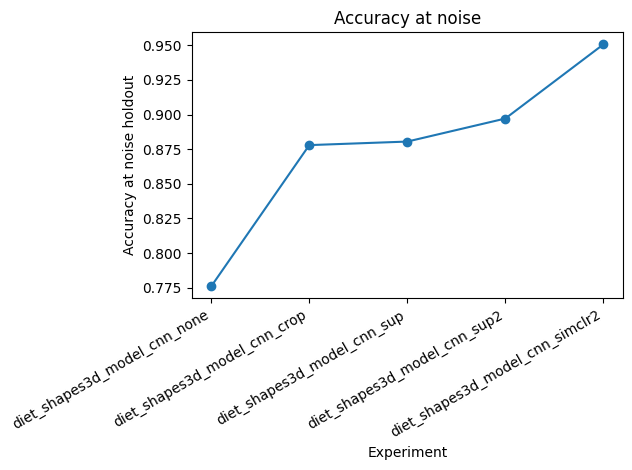

[np.float64(0.7760574259363936),
 np.float64(0.8779436011568219),
 np.float64(0.8805024125730858),
 np.float64(0.8971281682403602),
 np.float64(0.9506242586453055)]

In [44]:
import numpy as np
import matplotlib.pyplot as plt


x = []
y = []

for i, experiment in enumerate(experiments):
    agg_ = agg[agg.condition == experiment]

    vals = agg_[
        (agg_.split == 'adv') &
        (agg_.coordinate_idx == 4)
    ].iloc[:, 4]

    mean_val = vals.mean()  # equivalent to np.mean(vals)

    x.append(i)
    y.append(mean_val)

plt.figure()

# line connecting points (with markers)
plt.plot(x, y, marker='o')

# optional: keep scatter too (redundant, but fine)
# plt.scatter(x, y)

plt.xticks(x, experiments, rotation=30, ha="right")
plt.xlabel("Experiment")
plt.ylabel("Accuracy at noise holdout")
plt.title("Accuracy at noise")

plt.tight_layout()
plt.show()
y

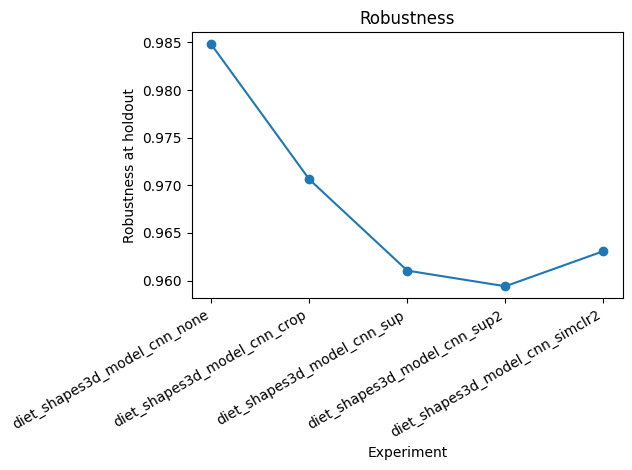

[np.float64(0.9847905488945492),
 np.float64(0.9706200835880902),
 np.float64(0.9610414658479605),
 np.float64(0.9593995629577173),
 np.float64(0.9630812501850715)]

In [45]:
import numpy as np
import matplotlib.pyplot as plt


x = []
y = []

for i, experiment in enumerate(experiments):
    agg_ = agg[agg.condition == experiment]

    vals = 1- ( np.array(agg_[
        (agg_.split == 'val') &
        (agg_.coordinate_idx == 4) 
    ].iloc[:, 4]) -  np.array(agg_[
        (agg_.split == 'adv') &
        (agg_.coordinate_idx == 4) 
    ].iloc[:, 4])) / np.array(agg_[
        (agg_.split == 'val') &
        (agg_.coordinate_idx == 4) 
    ].iloc[:, 4])

    mean_val = np.mean(vals)  # or vals.mean()

    x.append(i)               # numeric x-position
    y.append(mean_val)

plt.figure()
plt.plot(x, y, marker='o')

plt.xticks(x, experiments, rotation=30, ha="right")
plt.xlabel("Experiment")
plt.ylabel("Robustness at holdout")
plt.title("Robustness")

plt.tight_layout()
plt.show()
y

len(x) = 5 len(ident) = 5 len(acc) = 5 len(rob) = 5


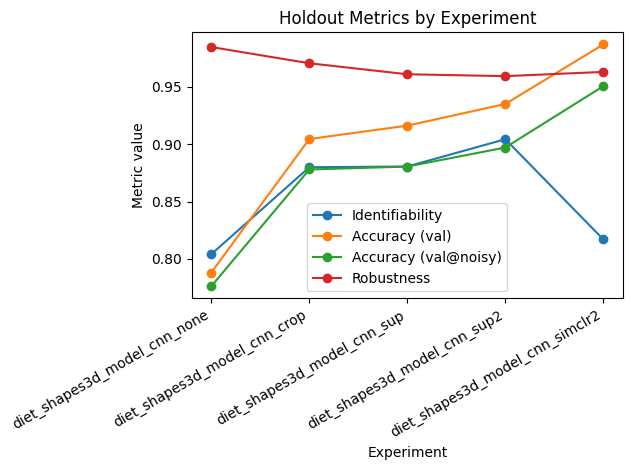

In [46]:
import numpy as np
import matplotlib.pyplot as plt



x = list(range(len(experiments)))

ident = []
acc = []
acc_adv = []
rob = []

for experiment in experiments:
    agg_ = agg[agg.condition == experiment]

    # Identifiability
    ident_vals = agg_.loc[
        (agg_.split == 'val') &
        (agg_.coordinate_idx != 4), 
        #(agg_.coordinate_idx > 0) &
        #(agg_.coordinate_idx != 2),
        agg_.columns[4]
    ]
    ident.append(ident_vals.mean())

    # Accuracy at holdout
    acc_vals = agg_.loc[
        (agg_.split == 'val') &
        (agg_.coordinate_idx == 4),
        agg_.columns[4]
    ]
    acc.append(acc_vals.mean())

    # Accuracy-noise at holdout
    acc_advs = agg_.loc[
        (agg_.split == 'adv') &
        (agg_.coordinate_idx == 4),
        agg_.columns[4]
    ]
    acc_adv.append(acc_advs.mean())

    # Robustness at holdout
    v = agg_.loc[
        (agg_.split == 'val') &
        (agg_.coordinate_idx == 4),
        agg_.columns[4]
    ].to_numpy()

    a = agg_.loc[
        (agg_.split == 'adv') &
        (agg_.coordinate_idx == 4),
        agg_.columns[4]
    ].to_numpy()

    n = min(len(v), len(a))
    if n == 0:
        rob.append(np.nan)
    else:
        v = v[:n]
        a = a[:n]
        v_safe = np.where(v == 0, np.nan, v)
        rob_vals = 1 - ((v - a) / v_safe)
        rob.append(np.nanmean(rob_vals))

# Quick sanity check (optional)
print("len(x) =", len(x), "len(ident) =", len(ident), "len(acc) =", len(acc), "len(rob) =", len(rob))

plt.figure()
plt.plot(x, ident, marker='o', label='Identifiability')
plt.plot(x, acc,   marker='o', label='Accuracy (val)')
plt.plot(x, acc_adv,   marker='o', label='Accuracy (val@noisy)')
plt.plot(x, rob,   marker='o', label='Robustness')

plt.xticks(x, experiments, rotation=30, ha="right")
plt.xlabel("Experiment")
plt.ylabel("Metric value")
plt.title("Holdout Metrics by Experiment")
plt.legend()
plt.tight_layout()
plt.show()


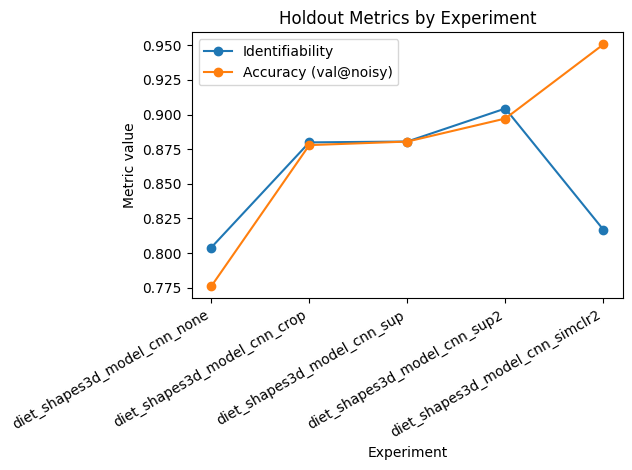

([np.float64(0.8040178928804584),
  np.float64(0.87990646307998),
  np.float64(0.8805421977522085),
  np.float64(0.9043518889109514),
  np.float64(0.8169208258609478)],
 [np.float64(0.7760574259363936),
  np.float64(0.8779436011568219),
  np.float64(0.8805024125730858),
  np.float64(0.8971281682403602),
  np.float64(0.9506242586453055)])

In [47]:
plt.figure()
plt.plot(x, ident, marker='o', label='Identifiability')

plt.plot(x, acc_adv,   marker='o', label='Accuracy (val@noisy)')
#plt.plot(x, rob,   marker='o', label='Robustness')

plt.xticks(x, experiments, rotation=30, ha="right")
plt.xlabel("Experiment")
plt.ylabel("Metric value")
plt.title("Holdout Metrics by Experiment")
plt.legend()
plt.tight_layout()
plt.show()
ident, acc_adv

([np.float64(0.8040178928804584),
  np.float64(0.87990646307998),
  np.float64(0.8805421977522085),
  np.float64(0.9043518889109514),
  np.float64(0.8169208258609478)],
 [np.float64(0.9847905488945492),
  np.float64(0.9706200835880902),
  np.float64(0.9610414658479605),
  np.float64(0.9593995629577173),
  np.float64(0.9630812501850715)])

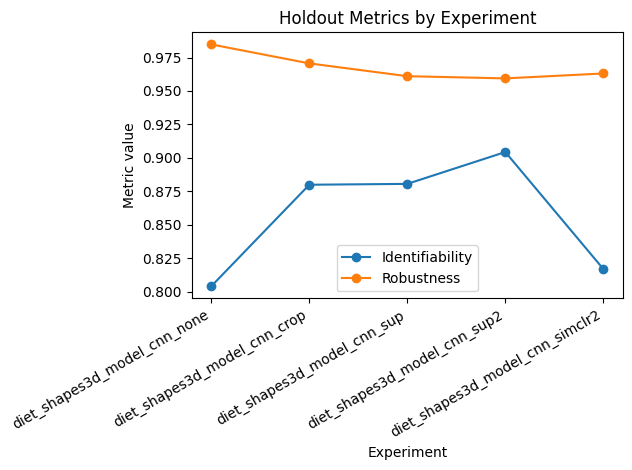

In [48]:
plt.figure()
plt.plot(x, ident, marker='o', label='Identifiability')

#plt.plot(x, acc_adv,   marker='o', label='Accuracy (val@noisy)')
plt.plot(x, rob,   marker='o', label='Robustness')

plt.xticks(x, experiments, rotation=30, ha="right")
plt.xlabel("Experiment")
plt.ylabel("Metric value")
plt.title("Holdout Metrics by Experiment")
plt.legend()
plt.tight_layout()
ident, rob

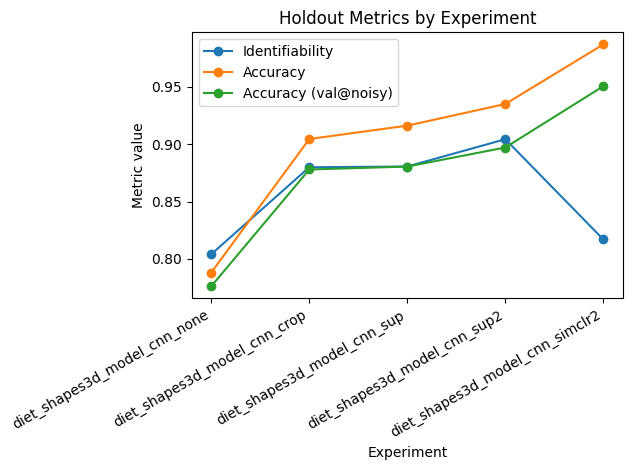

In [49]:
plt.figure()
plt.plot(x, ident, marker='o', label='Identifiability')
plt.plot(x, acc,   marker='o', label='Accuracy')
plt.plot(x, acc_adv,   marker='o', label='Accuracy (val@noisy)')


plt.xticks(x, experiments, rotation=30, ha="right")
plt.xlabel("Experiment")
plt.ylabel("Metric value")
plt.title("Holdout Metrics by Experiment")
plt.legend()
plt.tight_layout()